In [ ]:
# The idea of this notebook is try to predict the intensity values measured by Klio with the best model of Wakayama

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

In [10]:
# importing of klio data set
klio_df = pd.read_excel('data/Klio_CID_unique_preferred_Imax_FIXED.xlsx', sheet_name='CID_unique')
print(klio_df.shape)
print(klio_df.columns)
klio_df.head()

(1500, 12)
Index(['CID', 'Canonical_Name', 'CAS', 'Preferred_Imax', 'N_records',
       'Sources', 'Imax_mean', 'Imax_min', 'Imax_max', 'Klio_names', 'SMILES',
       'IUPACName'],
      dtype='str')


,CID,Canonical_Name,CAS,Preferred_Imax,N_records,Sources,Imax_mean,Imax_min,Imax_max,Klio_names,SMILES,IUPACName
0,107,3-PHENYLPROPIONIC ACID,501-52-0,46.0,1,Original,46.0,46.0,46.0,phrenyl propionic acid-3,C1=CC=C(C=C1)CCC(=O)O,3-phenylpropanoic acid
1,125,4-HYDROXYBENZYL ALCOHOL,623-05-2,17.0,1,Original,17.0,17.0,17.0,NaN,C1=CC(=CC=C1CO)O,4-(hydroxymethyl)phenol
2,176,ACETIC ACID,64-19-7,100.0,2,Reevaluation,100.0,100.0,100.0,NaN,CC(=O)O,acetic acid
3,177,ACETALDEHYDE,75-07-0,59.0,1,Reevaluation,59.0,59.0,59.0,acetaldehyde,CC=O,acetaldehyde
4,179,ACETOIN NATURAL,513-86-0,49.0,2,Reevaluation,49.0,49.0,49.0,acetoin 1%,CC(C(=O)C)O,3-hydroxybutan-2-one


In [11]:
# delete all rows which contains dilution (probably '%' in column 'Klio_names')
#regex=False means treat '%' as literal string, na=False, syas in terms of Nana do not return Nan
klio_df = klio_df[ 
    ~klio_df['Klio_names'].astype(str).str.contains('%', regex=False, na=False)
].copy()
print(klio_df.shape)

(1483, 12)


In [4]:
klio_df

,CID,Canonical_Name,CAS,Preferred_Imax,N_records,Sources,Imax_mean,Imax_min,Imax_max,Klio_names,SMILES,IUPACName
0,107,3-PHENYLPROPIONIC ACID,501-52-0,46.0,1,Original,46.0,46.0,46.0,phrenyl propionic acid-3,C1=CC=C(C=C1)CCC(=O)O,3-phenylpropanoic acid
1,125,4-HYDROXYBENZYL ALCOHOL,623-05-2,17.0,1,Original,17.0,17.0,17.0,NaN,C1=CC(=CC=C1CO)O,4-(hydroxymethyl)phenol
2,176,ACETIC ACID,64-19-7,100.0,2,Reevaluation,100.0,100.0,100.0,NaN,CC(=O)O,acetic acid
3,177,ACETALDEHYDE,75-07-0,59.0,1,Reevaluation,59.0,59.0,59.0,acetaldehyde,CC=O,acetaldehyde
5,180,ACETONE,67-64-1,57.0,1,Original,57.0,57.0,57.0,acetone,CC(=O)C,propan-2-one
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,144074858,COCOA INC. EPURE,8002-31-1,27.0,1,Reevaluation,27.0,27.0,27.0,cocoa shell extract,CC1/C=C\C2=CC=CC=C2NCCC3=C(C=C4CCC[N+]5=CC=CC=...,(25Z)-27-methyl-14-propan-2-yl-18-aza-8-azonia...
1496,154733642,CREMOPHORE RH-40 SURFACTANT,61788-85-0,0.0,3,Original,0.0,0.0,0.0,NaN,CCCCCCC(CCCCCCCCCCOC(=O)OCCOCC(COCCOC(=O)OCCCC...,"2-[1,3-bis[2-(11-hydroxyheptadecoxycarbonyloxy..."
1497,162130518,LABDANUM OIL (DECOLORED),8016-26-0,40.0,3,Reevaluation,40.0,40.0,40.0,Labdanum abs,[B].[B].C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C....,NaN
1498,167312552,LAVANDIN GROSSO OIL,8022-15-9,32.0,1,Reevaluation,32.0,32.0,32.0,lavandin absolute,CC1=NC=C(C=C1)C=CC2=CC=C(C=C2)N(C)CCC(C)C.CC1=...,2-[2-[N-(2-hydroxyethyl)-4-[2-(6-methyl-3-pyri...


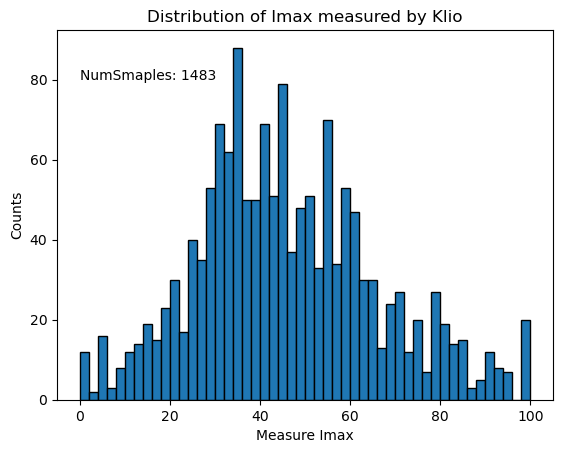

In [12]:
plt.hist(klio_df['Preferred_Imax'], bins=50, edgecolor='black')
plt.title('Distribution of Imax measured by Klio')
plt.xlabel('Measure Imax')
plt.ylabel('Counts')
plt.text(0.0, 80, f"NumSmaples: {klio_df.shape[0]}")
plt.show()

In [13]:
# experimental VP table
vp_exp_df = pd.read_csv('data/output_vp_full_v4.csv')

vp_exp_df = vp_exp_df[['CID', 'vp_mmhg_pubchem_clean']].copy()
vp_exp_df = vp_exp_df.rename(columns={'vp_mmhg_pubchem_clean': 'vp_exp'})
vp_exp_df = vp_exp_df.dropna(subset=['vp_exp'])
vp_exp_df = vp_exp_df[vp_exp_df['vp_exp'] > 0]
vp_exp_df = vp_exp_df.drop_duplicates(subset='CID', keep='first')

In [14]:
dragon_df = pd.read_csv('data/raw_dragon_matrix.csv')
dragon_df

,CID,MW,AMW,Sv,Se,Sp,Si,Mv,Me,Mp,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,126,122.130000,8.142,10.010,15.3050,10.193000,16.664000,0.667,1.020,0.680,...,66.806000,113.420000,0.864,-2.37,-2.42,-2.39,1.0,40.0,0.000,0
1,176,60.060000,7.507,4.483,8.4220,4.896675,9.249000,0.560,1.053,0.554,...,36.165462,58.100000,0.684,-1.06,-0.95,-0.84,0.0,12.0,0.000,0
2,177,57.375125,6.294,4.483,7.7353,4.896675,8.566025,0.538,1.013,0.568,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.000,0
3,179,88.120000,6.294,7.537,14.1890,7.955000,16.080000,0.538,1.014,0.568,...,54.205000,92.700000,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0
4,180,58.090000,5.809,5.295,9.9780,5.739000,11.455000,0.530,0.998,0.574,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,12.0,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4060,101297586,220.390000,5.510,22.036,38.9310,24.591000,45.192000,0.551,0.973,0.615,...,138.010000,246.850000,0.887,-4.46,-4.75,-4.84,3.0,86.0,0.027,0
4061,101306697,222.410000,5.295,22.563,40.8140,25.353000,47.607000,0.537,0.972,0.604,...,140.938000,249.490000,0.844,-4.55,-4.86,-4.95,2.0,88.0,0.022,0
4062,121232748,208.330000,5.952,19.698,34.4910,21.523000,39.571000,0.563,0.985,0.615,...,122.822000,221.040000,0.880,-3.96,-4.19,-4.26,3.0,78.0,0.029,0
4063,121237820,224.380000,5.609,21.751,39.2580,24.046000,45.401000,0.544,0.981,0.601,...,139.808000,250.700000,0.884,-4.19,-4.44,-4.52,1.0,68.0,0.022,0


In [15]:
# Now i need merge between klio_df and dragon according to 'CID
klio_df = klio_df[['CID', 'Canonical_Name', 'Preferred_Imax']].copy()
klio_df.rename(columns={'Preferred_Imax' : 'Imax'}, inplace=True)
klio_df

,CID,Canonical_Name,Imax
0,107,3-PHENYLPROPIONIC ACID,46.0
1,125,4-HYDROXYBENZYL ALCOHOL,17.0
2,176,ACETIC ACID,100.0
3,177,ACETALDEHYDE,59.0
5,180,ACETONE,57.0
...,...,...,...
1495,144074858,COCOA INC. EPURE,27.0
1496,154733642,CREMOPHORE RH-40 SURFACTANT,0.0
1497,162130518,LABDANUM OIL (DECOLORED),40.0
1498,167312552,LAVANDIN GROSSO OIL,32.0


In [16]:
print("Number of duplicates", klio_df['CID'].duplicated().sum())

Number of duplicates 0


In [20]:
klio_dragon_merge = pd.merge(
    klio_df,
    dragon_df,
    on='CID',
    how='left'
)
print(klio_dragon_merge.shape)

(1483, 2493)


In [21]:
klio_dragon_merge = klio_dragon_merge.dropna(axis=0)
klio_dragon_merge.shape

(1254, 2493)

In [ ]:
# Check the duplicates
print(klio_dragon_merge.duplicated().sum())

0


In [ ]:
klio_dragon_merge.head()

,CID,Canonical_Name,Imax,MW,AMW,Sv,Se,Sp,Si,Mv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,107,3-PHENYLPROPIONIC ACID,46.0,150.190000,7.152,13.064,21.0730,13.716000,23.495000,0.622,...,85.991000,148.020000,0.875,-3.16,-3.30,-3.31,1.0,48.0,0.028,0.0
1,125,4-HYDROXYBENZYL ALCOHOL,17.0,124.150000,7.303,10.537,17.1890,10.955000,19.080000,0.620,...,69.734000,116.060000,0.822,-2.22,-2.25,-2.21,1.0,40.0,0.052,0.0
2,176,ACETIC ACID,100.0,60.060000,7.507,4.483,8.4220,4.896675,9.249000,0.560,...,36.165462,58.100000,0.684,-1.06,-0.95,-0.84,0.0,12.0,0.000,0.0
3,177,ACETALDEHYDE,59.0,57.375125,6.294,4.483,7.7353,4.896675,8.566025,0.538,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.000,0.0
4,180,ACETONE,57.0,58.090000,5.809,5.295,9.9780,5.739000,11.455000,0.530,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,12.0,0.000,0.0


In [55]:
klio_dragon_merge.to_csv('data/klio_dragon_merged.csv')

In [24]:
mX_df = klio_dragon_merge.loc[:, 'MW':]

In [27]:
#first we remove features with zero variance
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0) #object 

mX1 = vt.fit_transform(mX_df) #returns NDArray

# mX1_df becomes the updated feature matrix
mX1_df = pd.DataFrame(
    mX1,
    columns=mX_df.columns[vt.get_support()],
    index=mX_df.index
)

print(mX1_df.shape)

(1254, 2490)


In [28]:
# correlations matrix
corr_matrix = mX1_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95) # May be the correlation threshold should be lower
]

print(f"Descriptors to remove: {len(to_drop)}")

Descriptors to remove: 1612


In [29]:
# Dropping of high correlated descriptors
mX2_df = mX1_df.drop(columns=to_drop)
print(mX2_df.shape)

(1254, 878)


In [32]:
vY_Imax = klio_dragon_merge['Imax']

In [33]:
xgb_reg = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(mX2_df, vY_Imax)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [34]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX2_df.columns
).sort_values(ascending=False)

importance.head(60)

SM05_AEA_dm_      0.012116
Wap               0.010529
ChiA_Dz_Z_        0.010175
Mor05v            0.008560
SpMax5_Bh_s_      0.008241
Mor05m            0.007703
SpMax6_Bh_s_      0.006537
SM10_AEA_bo_      0.005014
RDF015s           0.003715
Psi_i_s           0.003465
HTs               0.003410
Psi_i_t           0.003322
SpMaxA_AEA_dm_    0.002983
SpMax2_Bh_s_      0.002842
SpMaxA_EA_bo_     0.002717
R7s               0.002655
TPSA_NO_          0.002613
H3s               0.002448
P_VSA_v_2         0.002432
RDF140u           0.002412
SM14_AEA_bo_      0.002358
H3m               0.002306
Mor07m            0.002280
WiA_Dt            0.002271
ATSC8e            0.002267
RDF040v           0.002179
Chi0_EA_dm_       0.002148
TDB03s            0.002147
SaaN              0.002120
Mor03m            0.002114
SpMax3_Bh_s_      0.002104
ATSC1e            0.002075
ATSC7s            0.002066
Mor32v            0.002048
H0e               0.002043
Mor10m            0.002041
MPC07             0.002022
T

In [35]:
top60_reg_features = importance.index[:60]

top60_reg_features

Index(['SM05_AEA_dm_', 'Wap', 'ChiA_Dz_Z_', 'Mor05v', 'SpMax5_Bh_s_', 'Mor05m',
       'SpMax6_Bh_s_', 'SM10_AEA_bo_', 'RDF015s', 'Psi_i_s', 'HTs', 'Psi_i_t',
       'SpMaxA_AEA_dm_', 'SpMax2_Bh_s_', 'SpMaxA_EA_bo_', 'R7s', 'TPSA_NO_',
       'H3s', 'P_VSA_v_2', 'RDF140u', 'SM14_AEA_bo_', 'H3m', 'Mor07m',
       'WiA_Dt', 'ATSC8e', 'RDF040v', 'Chi0_EA_dm_', 'TDB03s', 'SaaN',
       'Mor03m', 'SpMax3_Bh_s_', 'ATSC1e', 'ATSC7s', 'Mor32v', 'H0e', 'Mor10m',
       'MPC07', 'TIE', 'GATS1e', 'G2v', 'HATS1v', 'Mor12v', 'Hy',
       'SpMaxA_B_s_', 'Eta_sh_p', 'Mor02m', 'D_Dtr06', 'JGI4', 'SM08_AEA_dm_',
       'VE2_G_D', 'HyWi_B_s_', 'SpMin4_Bh_s_', 'RTu_', 'ATS6m', 'H7s',
       'GATS2i', 'DELS', 'Mor11u', 'ATS3s', 'Mor13u'],
      dtype='str')

In [36]:
X_top60_reg = mX2_df[top60_reg_features].copy()

print(X_top60_reg.shape)

(1254, 60)


In [38]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_reg,
    X_top60_reg,
    vY_Imax,
    scoring="neg_mean_absolute_error",
    cv=cv
)

print("CV MAE:", -scores.mean())
print("STD:", scores.std())

CV MAE: 11.712565512976576
STD: 0.7243596234877351


In [39]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX2_df.columns
).sort_values(ascending=False)

In [40]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(10, 61, 5):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,10,12.291663,0.395298
1,15,12.000327,0.423391
2,20,11.881260,0.432895
3,25,11.934501,0.429425
4,30,11.846872,0.437485
5,35,11.712148,0.446745
6,40,11.662261,0.452883
7,45,11.601531,0.460938
8,50,11.634105,0.458699
9,55,11.655572,0.458072


In [41]:
results_df.sort_values('MAE')

,n_features,MAE,R2
7,45,11.601531,0.460938
8,50,11.634105,0.458699
9,55,11.655572,0.458072
6,40,11.662261,0.452883
5,35,11.712148,0.446745
10,60,11.712817,0.448817
4,30,11.846872,0.437485
2,20,11.881260,0.432895
3,25,11.934501,0.429425
1,15,12.000327,0.423391


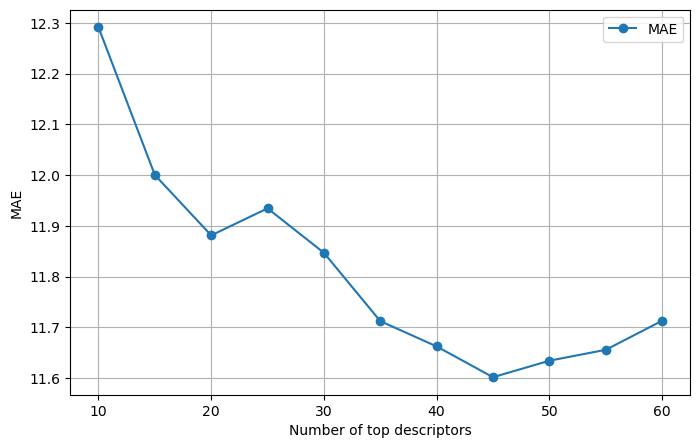

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE'
)

plt.xlabel('Number of top descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

In [43]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(35, 57, 1):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,35,11.712148,0.446745
1,36,11.713144,0.445675
2,37,11.773159,0.445965
3,38,11.792544,0.441760
4,39,11.659235,0.450889
5,40,11.662261,0.452883
6,41,11.691496,0.452327
7,42,11.709619,0.450631
8,43,11.583018,0.457087
9,44,11.659984,0.457122


In [44]:
results_df.sort_values('MAE')

,n_features,MAE,R2
8,43,11.583018,0.457087
10,45,11.601531,0.460938
18,53,11.618137,0.459660
17,52,11.632139,0.457243
15,50,11.634105,0.458699
16,51,11.635976,0.458240
11,46,11.641724,0.453416
21,56,11.646635,0.455977
20,55,11.655572,0.458072
4,39,11.659235,0.450889


In [45]:
top43 = importance.index[:43]
X43 = mX2_df[top43].copy()

print(X43.shape)
print(top43)

(1254, 43)
Index(['SM05_AEA_dm_', 'Wap', 'ChiA_Dz_Z_', 'Mor05v', 'SpMax5_Bh_s_', 'Mor05m',
       'SpMax6_Bh_s_', 'SM10_AEA_bo_', 'RDF015s', 'Psi_i_s', 'HTs', 'Psi_i_t',
       'SpMaxA_AEA_dm_', 'SpMax2_Bh_s_', 'SpMaxA_EA_bo_', 'R7s', 'TPSA_NO_',
       'H3s', 'P_VSA_v_2', 'RDF140u', 'SM14_AEA_bo_', 'H3m', 'Mor07m',
       'WiA_Dt', 'ATSC8e', 'RDF040v', 'Chi0_EA_dm_', 'TDB03s', 'SaaN',
       'Mor03m', 'SpMax3_Bh_s_', 'ATSC1e', 'ATSC7s', 'Mor32v', 'H0e', 'Mor10m',
       'MPC07', 'TIE', 'GATS1e', 'G2v', 'HATS1v', 'Mor12v', 'Hy'],
      dtype='str')


In [46]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_base = XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X43, vY_Imax)

print("Best CV MAE:", -grid.best_score_)
print("Best params:")
print(grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV MAE: 11.510395731206845
Best params:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.7}


In [50]:
best_xgb = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=4,
    n_estimators=500,
    subsample=0.7,
    random_state=42
)

In [51]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    best_xgb,
    X43,
    vY_Imax,
    cv=cv
)

In [52]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(vY_Imax, y_pred)
r2 = r2_score(vY_Imax, y_pred)

print(f"MAE = {mae:.3f}")
print(f"R²  = {r2:.3f}")

MAE = 11.706
R²  = 0.449


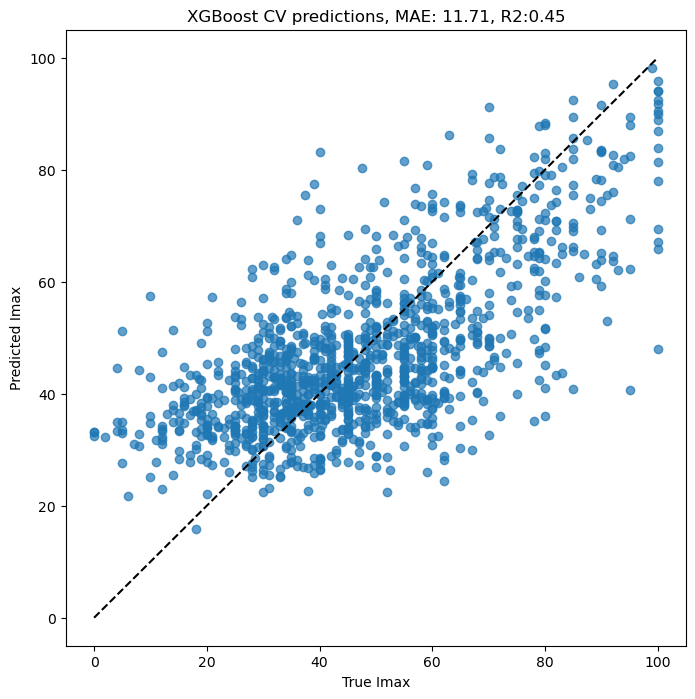

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(vY_Imax, y_pred, alpha=0.7)

plt.plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title(f"XGBoost CV predictions, MAE: {mae:.2f}, R2:{r2:.2f}")

plt.show()

In [56]:
X43

,SM05_AEA_dm_,Wap,ChiA_Dz_Z_,Mor05v,SpMax5_Bh_s_,Mor05m,SpMax6_Bh_s_,SM10_AEA_bo_,RDF015s,Psi_i_s,...,Mor32v,H0e,Mor10m,MPC07,TIE,GATS1e,G2v,HATS1v,Mor12v,Hy
0,-2.000,412.0,0.0410,-1.729,3.674,-1.811,3.328000,2.149,15.770,29.333,...,-0.179,3.103,0.140,2.197,15.295,0.756,0.572,0.104,-0.145,-0.206
1,0.000,247.0,0.0740,-1.517,3.383,-1.618,2.605000,2.083,15.987,24.833,...,-0.201,3.125,0.229,1.099,10.260,1.046,0.275,0.114,0.070,0.736
2,0.000,9.0,0.3580,-0.398,0.999,-0.535,0.999000,-1.000,4.556,16.667,...,0.002,3.351,0.028,0.000,2.147,0.907,0.308,0.075,0.004,0.538
3,0.000,4.0,0.5674,-0.326,0.999,-0.380,0.572237,-1.000,4.007,11.000,...,0.027,3.152,-0.051,0.000,0.650,0.505,0.263,0.074,-0.044,-0.528
4,0.000,9.0,0.3250,-0.567,0.999,-0.558,0.999000,-1.000,6.660,12.667,...,0.023,3.121,0.013,0.000,2.388,0.500,0.231,0.083,-0.109,-0.646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,-1.310,944.0,0.0240,-3.105,3.892,-2.597,3.855000,2.561,29.021,34.333,...,-0.115,2.798,0.587,3.045,33.177,0.656,0.175,0.076,-0.274,-0.856
1469,-1.000,1710.0,0.0180,-2.588,3.824,-1.809,3.552000,2.070,30.939,31.000,...,-0.119,2.824,0.227,2.944,35.656,0.589,0.180,0.060,-1.243,-0.917
1473,-1.449,398.0,0.0210,-2.584,3.636,-1.778,3.476000,2.228,26.127,30.333,...,-0.027,2.799,0.572,2.197,47.765,0.716,0.160,0.048,-1.119,-0.835
1474,-0.660,5736.0,0.0190,-4.049,3.780,-3.471,3.694000,3.328,35.279,37.083,...,-0.321,2.824,0.647,4.762,36.515,0.676,0.163,0.062,-1.377,-0.879
